# Exploring how the hits changed

We want to find a story about how Billboard hits have changed. We begin with the overall sound and length of charting songs, look more closely at genre and chart success, then check how missing audio and our counting choices affect the results.

This notebook uses the output of `clean.py` and `features.py`. The earlier notebooks cover the raw data and cleaning decisions. Here we work toward a choice of stories and figures for the report.

We use **1960–2019** so the main comparisons cover six full decades. Each song counts once, in the decade it first appears in the dataset. That is not necessarily its release decade. Audio comparisons use songs with all four core scores available; duration and genre use their own available data. We keep missing values in the source tables and create separate estimates only for the sensitivity analysis.

The notebook uses the processed files generated by the cleaning and feature scripts. It can be run from the repository root or the `notebooks` folder.


In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)

root = Path.cwd()
if not (root / 'data').exists():
    root = root.parent

processed = root / 'data' / 'processed'
songs = pd.read_csv(processed / 'songs_features.csv')
entries = pd.read_csv(processed / 'chart_entries.csv')

scores = ['valence', 'danceability', 'energy', 'acousticness']
decades = [1960, 1970, 1980, 1990, 2000, 2010]
main_genres = ['pop', 'rock', 'rap', 'r&b', 'country']

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 1. A few checks before plotting

The song table should have one row per song ID. The chart table can contain more than one entry for the same song in a week, so we check its song summaries using distinct dates. The repeated entries are discussed in the cleaning notes.


In [34]:
assert songs.song_id.is_unique
assert entries.song_id.isin(songs.song_id).all()
assert entries.position.between(1, 100).all()
assert songs.eda_core_complete.equals(songs[scores].notna().all(axis=1))

chart_summary = entries.groupby('song_id').agg(
    weeks=('chart_date', 'nunique'),
    best_rank=('position', 'min'),
)
check = songs.set_index('song_id').join(chart_summary)
assert (check.observed_chart_weeks == check.weeks).all()
assert (check.best_observed_rank == check.best_rank).all()

sample = songs[songs.first_observed_year.between(1960, 2019)].copy()
sample['top10'] = sample.best_observed_rank <= 10
audio = sample[sample.eda_core_complete].copy()
lengths = sample.dropna(subset=['duration_minutes']).copy()

print(f'All song IDs: {len(songs):,}')
print(f'Songs first charting in 1960–2019: {len(sample):,}')
print(f'With core audio scores: {len(audio):,}')
print(f'With duration: {len(lengths):,}')
print('Repeated song/date pairs:', entries.duplicated(['song_id', 'chart_date']).sum())


All song IDs: 29,389
Songs first charting in 1960–2019: 27,549
With core audio scores: 23,039
With duration: 23,096
Repeated song/date pairs: 13


We have 27,549 songs in the main period and 23,039 with core audio scores. We leave missing scores missing rather than fill them with zero. Also, `audio_row_matched` in the current pipeline means a Spotify track ID is present; it does not mean that all audio scores are available or that the recording match is correct.

These checks establish the shape of the data, not whether every Spotify match is right. We start with the available measurements and return to coverage and matching issues after exploring the main patterns.

## 2. The overall sound of the charts

We start with the four core scores on the same sample.


,valence,danceability,energy,acousticness
decade,,,,
1960,0.696,0.538,0.510,0.579
1970,0.708,0.581,0.592,0.282
1980,0.703,0.634,0.675,0.124
1990,0.602,0.662,0.666,0.082
2000,0.557,0.623,0.738,0.072
2010,0.466,0.641,0.690,0.083


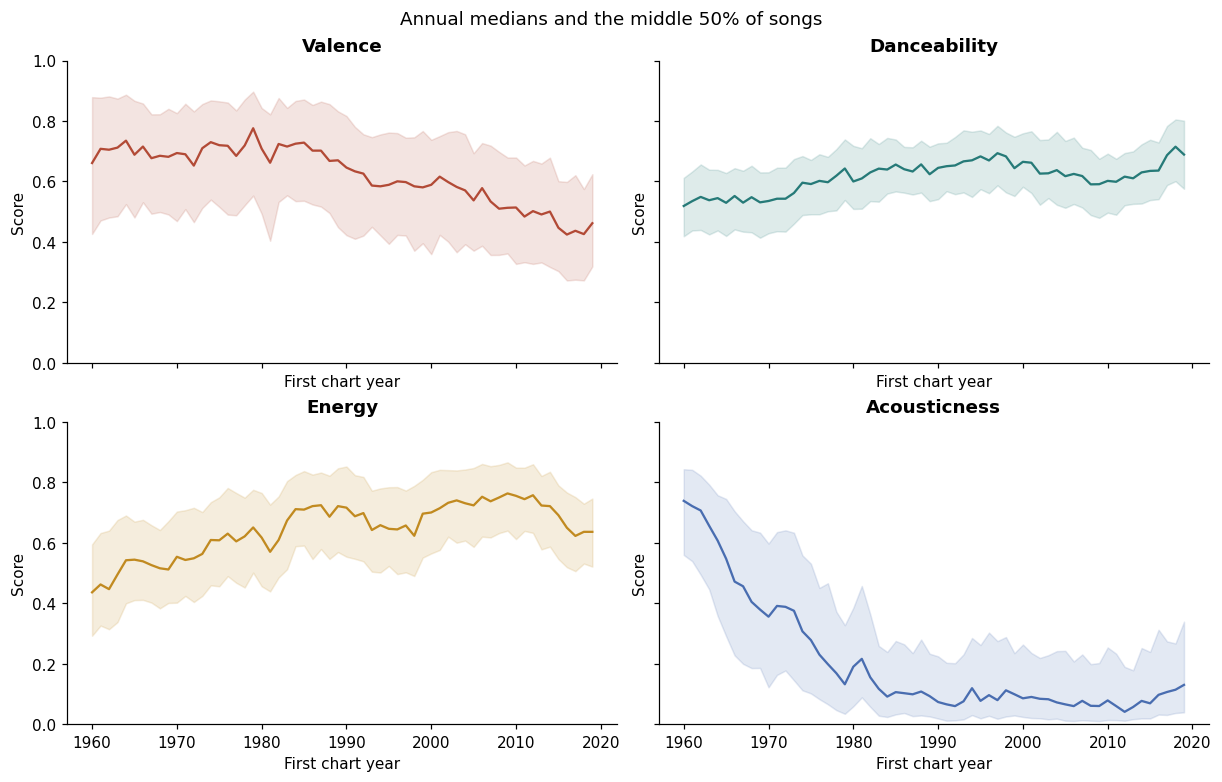

In [35]:
medians = audio.groupby('decade')[scores].median()
display(medians.round(3))

colors = ['#b24a36', '#267a78', '#c18a20', '#496db0']
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True, constrained_layout=True)
for ax, score, color in zip(axes.flat, scores, colors):
    yearly = audio.groupby('first_observed_year')[score]
    median = yearly.median()
    lower = yearly.quantile(0.25)
    upper = yearly.quantile(0.75)
    ax.plot(median.index, median, color=color)
    ax.fill_between(median.index, lower, upper, color=color, alpha=0.15)
    ax.set(title=score.capitalize(), xlabel='First chart year', ylabel='Score', ylim=(0, 1))
fig.suptitle('Annual medians and the middle 50% of songs')
plt.show()


Valence stays near 0.70 through the 1980s and then falls. Danceability is higher in recent decades, while energy peaks in the 2000s rather than rising continuously. Acousticness has the largest early decline: its median falls from 0.579 in the 1960s to 0.124 in the 1980s, then changes much less. There is a small rise from the 2000s to the 2010s.

The shaded bands show variation between songs, not confidence intervals. There is plenty of overlap between periods, so we should avoid writing as if every old song sounds one way and every new song sounds another.

This gives us two leads: lower valence alongside higher danceability, and an earlier shift away from high acousticness. Before narrowing the story, we also look at song length.

## 3. Song length: shorter than when?

The reference period matters. We compare the full distribution, the typical length, and the share of songs under three minutes. Duration describes the Spotify recording, which may be different from the version that charted.


,songs,median_minutes,under_three_minutes
decade,,,
1960,5229,2.652,0.776
1970,4213,3.556,0.213
1980,3513,4.133,0.047
1990,2810,4.301,0.033
2000,3137,3.904,0.047
2010,4194,3.591,0.142


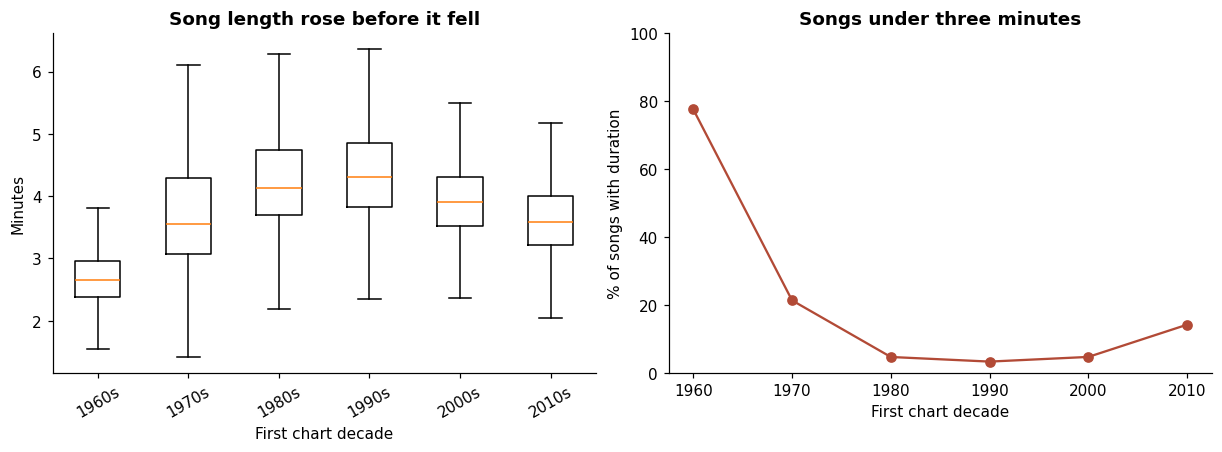

,All durations,Excluding >10 minutes,Difference in seconds
decade,,,
1960,2.652,2.652,-0.027
1970,3.556,3.553,-0.174
1980,4.133,4.132,-0.036
1990,4.301,4.300,-0.033
2000,3.904,3.904,-0.013
2010,3.591,3.591,-0.041


In [36]:
lengths['under_three_minutes'] = lengths.duration_minutes < 3
length_summary = lengths.groupby('decade').agg(
    songs=('song_id', 'size'),
    median_minutes=('duration_minutes', 'median'),
    under_three_minutes=('under_three_minutes', 'mean'),
)
display(length_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].boxplot([lengths.loc[lengths.decade == d, 'duration_minutes'] for d in decades], showfliers=False)
axes[0].set_xticks(range(1, 7), [f'{d}s' for d in decades], rotation=30)
axes[0].set(title='Song length rose before it fell', ylabel='Minutes', xlabel='First chart decade')
axes[1].plot(length_summary.index, length_summary.under_three_minutes * 100, marker='o', color='#b24a36')
axes[1].set(title='Songs under three minutes', ylabel='% of songs with duration', xlabel='First chart decade', ylim=(0, 100))
plt.show()

# Keep all records in the main result; remove very long tracks only for this check.
without_long_tracks = lengths[lengths.duration_minutes <= 10].groupby('decade').duration_minutes.median()
length_check = pd.DataFrame({'All durations': length_summary.median_minutes, 'Excluding >10 minutes': without_long_tracks})
length_check['Difference in seconds'] = (length_check['Excluding >10 minutes'] - length_check['All durations']) * 60
display(length_check.round(3))


Median duration rises from about 2:39 in the 1960s to 4:18 in the 1990s, then falls to 3:35 in the 2010s. Songs under three minutes rise from 3.3% in the 1990s to 14.2% in the 2010s, but were much more common in the 1960s: 77.6%.

The boxplots hide individual outlier points but retain them in the calculations. Boxes show the middle 50%, and whiskers use the usual 1.5-IQR rule. Removing recordings longer than ten minutes changes each decade median by less than 0.2 seconds. That deals with extreme durations, not all possible recording mismatches.

A decade summary may hide a more recent shift, so we look at annual medians from 1990 onward.


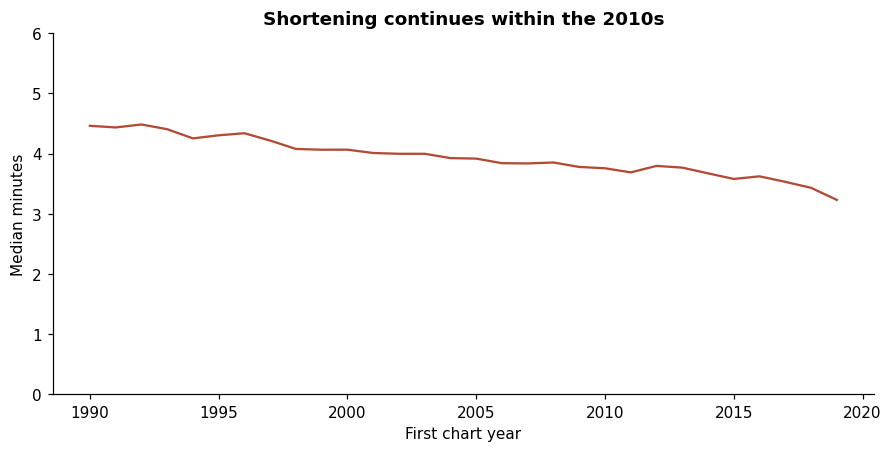

,count,median
first_observed_year,,
2010,428,3.757
2015,379,3.579
2019,497,3.231


In [37]:
recent_lengths = lengths[lengths.first_observed_year >= 1990]
yearly_length = recent_lengths.groupby('first_observed_year').duration_minutes.agg(['count', 'median'])

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(yearly_length.index, yearly_length['median'], color='#b24a36')
ax.set(title='Shortening continues within the 2010s', xlabel='First chart year',
       ylabel='Median minutes', ylim=(0, 6))
plt.show()
display(yearly_length.loc[[2010, 2015, 2019]].round(3))


The annual median falls from about 3:45 in 2010 to 3:14 in 2019.

**Story option:** “Short songs are making a comeback, not appearing for the first time.” A duration distribution by decade and the under-three-minute share make this clear. The annual view adds detail about recent changes. We cannot attribute the pattern to streaming from this comparison alone.

## 4. Lower valence, but still danceable?

The earlier plots showed falling valence and relatively high danceability. Separate medians do not show whether the **same songs** combine those traits.

For a first look we count songs with valence below 0.5 and danceability at least 0.5. This is an easy-to-explain cutoff, not a natural boundary between happy and sad songs. It is different from the existing `mood` feature, which uses energy rather than danceability.


### 3a. Does the streaming-era flag help explain song length?

We now use the existing `streaming_era` flag rather than introduce a new definition. In the supplied table, the last first-chart date labeled False is August 4, 2007, and the first labeled True is August 11, 2007. We verify that split below. These observed weekly dates locate the change in the stored labels; they do not establish the exact date or historical rationale used by the feature script.

We compare both the full 1960–2019 sample and two nearby ten-year windows: **August 11, 1997–August 10, 2007**, and **August 11, 2007–August 10, 2017**. Equal calendar windows reduce the imbalance in time covered, but do not make the periods otherwise comparable. Each song counts once, using its first observed chart date. Missing duration is excluded from duration summaries, with coverage reported separately.

,min,max
streaming_era,,
False,1960-01-02,2007-08-04
True,2007-08-11,2019-12-28


all_songs  with_duration  median_minutes  \
Comparison              Period                                                  
Full 1960–2019 sample   Before flag      22133          18013            3.62   
                        After flag        5416           5083            3.63   
Nearby ten-year windows Before flag       3250           2936            3.97   
                        After flag        4118           3869            3.70   

                                     under_three_pct  duration_coverage_pct  
Comparison              Period                                               
Full 1960–2019 sample   Before flag            29.45                  81.39  
                        After flag             12.83                  93.85  
Nearby ten-year windows Before flag             4.29                  90.34  
                        After flag              8.04                  93.95

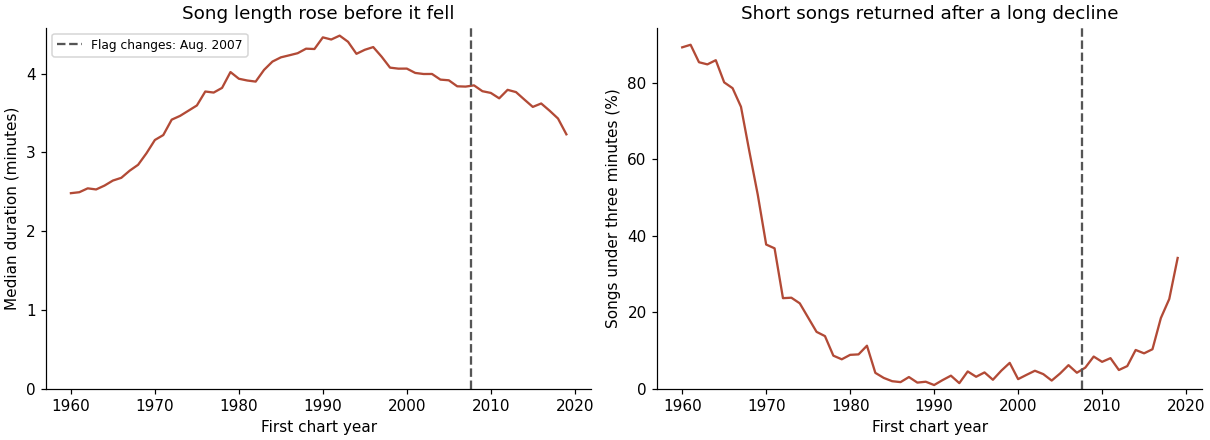

In [ ]:
# Inspect the supplied flag: do not replace it with a year >= 2007 rule.
stream_sample = sample.copy()
stream_sample['first_date'] = pd.to_datetime(stream_sample.first_observed_chart_date)
assert stream_sample.streaming_era.notna().all()
assert stream_sample.streaming_era.isin([True, False]).all()
flag_dates = stream_sample.groupby('streaming_era').first_date.agg(['min', 'max'])
display(flag_dates)
flag_boundary = stream_sample.loc[stream_sample.streaming_era, 'first_date'].min()
assert (stream_sample.streaming_era == (stream_sample.first_date >= flag_boundary)).all()

nearby = stream_sample[
    (stream_sample.first_date >= flag_boundary - pd.DateOffset(years=10))
    & (stream_sample.first_date < flag_boundary + pd.DateOffset(years=10))
].copy()

def summarize_duration_eras(data):
    # Keep missing duration out of the short-song denominator.
    data = data.copy()
    data['under_three'] = data.duration_minutes.lt(3).where(data.duration_minutes.notna())
    summary = data.groupby('streaming_era').agg(
        all_songs=('song_id', 'size'),
        with_duration=('duration_minutes', 'count'),
        median_minutes=('duration_minutes', 'median'),
        under_three_pct=('under_three', lambda x: x.mean() * 100),
    )
    summary['duration_coverage_pct'] = summary.with_duration / summary.all_songs * 100
    return summary.rename(index={False: 'Before flag', True: 'After flag'})

era_duration = pd.concat({
    'Full 1960–2019 sample': summarize_duration_eras(stream_sample),
    'Nearby ten-year windows': summarize_duration_eras(nearby),
}, names=['Comparison', 'Period'])
display(era_duration.round(2))

annual_duration = lengths.groupby('first_observed_year').agg(
    median_minutes=('duration_minutes', 'median'),
    under_three_pct=('duration_minutes', lambda x: x.lt(3).mean() * 100),
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, metric, title, ylabel in zip(
    axes, ['median_minutes', 'under_three_pct'],
    ['Song length rose before it fell', 'Short songs returned after a long decline'],
    ['Median duration (minutes)', 'Songs under three minutes (%)'],
):
    ax.plot(annual_duration.index, annual_duration[metric], color='#b24a36')
    ax.axvline(2007 + 7/12, color='#555555', linestyle='--', label='Flag changes: Aug. 2007')
    ax.set(title=title, xlabel='First chart year', ylabel=ylabel)
    ax.set_ylim(bottom=0)
axes[0].legend(fontsize=8)
plt.show()

The full-period split produces almost identical medians: **3.62 minutes before and 3.63 after**. It even shows fewer under-three-minute songs after the flag (**12.8% versus 29.4%**), because the earlier group includes the very short songs of the 1960s. This is why the flag alone is a poor summary of the historical pattern.

The nearby windows tell a different story: median duration falls from **3.97 to 3.70 minutes**, about **16 seconds**, and the under-three-minute share rises from **4.3% to 8.0%**. The annual plot places this comparison within a longer rise and fall; it does not show that shortening began at the flag boundary. The full-period and nearby results answer different questions, so we should present both rather than select whichever better supports a headline.

### Does the nearby duration difference also appear within genres?

We use the same ten-year windows and five large genre buckets. The table includes sample sizes and coverage; the plot requires at least 100 durations in each period. These artist-tag buckets are provisional, as discussed in Section 6. Differences within them cannot isolate streaming from other changes over time.

all_songs  with_duration  median_minutes  \
Genre   Period                                                  
pop     Before flag        649            616            3.88   
        After flag        1675           1609            3.68   
rock    Before flag        534            515            3.92   
        After flag         294            273            3.83   
rap     Before flag        628            576            4.17   
        After flag         935            891            3.92   
r&b     Before flag        383            362            4.29   
        After flag         111            105            4.03   
country Before flag        620            604            3.77   
        After flag         707            691            3.60   

                     under_three_pct  duration_coverage_pct  
Genre   Period                                               
pop     Before flag             2.27                  94.92  
        After flag              8.64                  96.06  
rock    Before flag             7.96                  96.44  
        After flag              5.49                  92.86  
rap     Before flag             2.43                  91.72  
        After flag              7.18                  95.29  
r&b     Before flag             1.38                  94.52  
        After flag              0.95                  94.59  
country Before flag             6.79                  97.42  
        After flag              6.95                  97.74

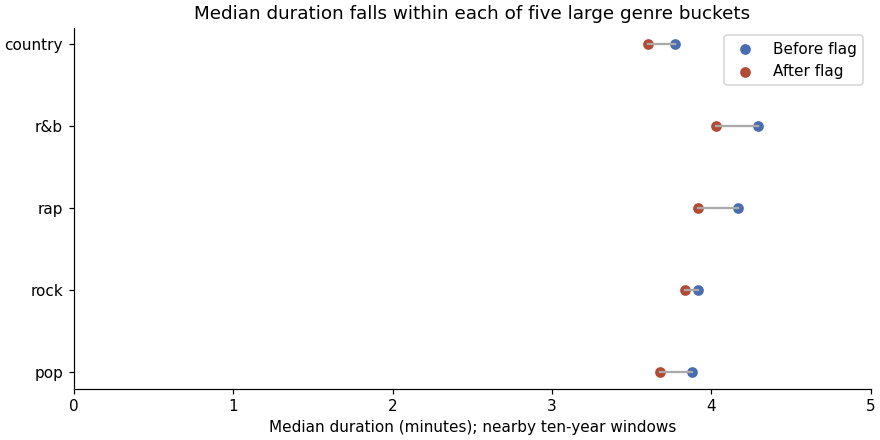

,Median change (seconds),Under-three-minute change (pp)
Genre,,
pop,-12.0,6.4
rock,-5.0,-2.5
rap,-15.0,4.8
r&b,-15.8,-0.4
country,-10.0,0.2


In [ ]:
genre_era_duration = pd.concat({
    genre: summarize_duration_eras(nearby[nearby.genre_bucket == genre])
    for genre in main_genres
}, names=['Genre', 'Period'])
display(genre_era_duration.round(2))
genre_duration_medians = genre_era_duration.median_minutes.unstack()
genre_duration_counts = genre_era_duration.with_duration.unstack()
genre_duration_medians = genre_duration_medians[(genre_duration_counts >= 100).all(axis=1)]

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for row, (genre, values) in enumerate(genre_duration_medians.iterrows()):
    ax.plot([values['Before flag'], values['After flag']], [row, row], color='#aaaaaa')
ax.scatter(genre_duration_medians['Before flag'], range(len(genre_duration_medians)),
           color='#496db0', label='Before flag')
ax.scatter(genre_duration_medians['After flag'], range(len(genre_duration_medians)),
           color='#b24a36', label='After flag')
ax.set_yticks(range(len(genre_duration_medians)), genre_duration_medians.index)
ax.set(title='Median duration falls within each of five large genre buckets',
       xlabel='Median duration (minutes); nearby ten-year windows', xlim=(0, 5))
ax.legend()
plt.show()

genre_duration_change = pd.DataFrame({
    'Median change (seconds)': (genre_duration_medians['After flag'] - genre_duration_medians['Before flag']) * 60,
    'Under-three-minute change (pp)': genre_era_duration.under_three_pct.unstack()['After flag']
        - genre_era_duration.under_three_pct.unstack()['Before flag'],
})
display(genre_duration_change.round(1))

Median duration falls within all five buckets, by about **5 seconds for rock to 16 seconds for R&B**. That suggests the aggregate shortening is not solely a shift between these broad categories. However, the under-three-minute share does not rise everywhere: it falls for rock and R&B and is nearly unchanged for country. A lower median does not automatically imply a larger very-short-song share.

**Implication:** the flag is useful for a supporting comparison, but the annual and decade plots remain the clearest evidence for the song-length story. We describe differences between periods, not an effect caused by streaming. Equal windows, within-genre comparisons, and available-data coverage do not remove confounding or recording-match uncertainty.

The annual median falls from about 3:45 in 2010 to 3:14 in 2019.

**Story option:** “Short songs are making a comeback, not appearing for the first time.” A duration distribution by decade and the under-three-minute share make this clear. The annual view adds detail about recent changes. We cannot attribute the pattern to streaming from this comparison alone.

## 4. Lower valence, but still danceable?

The earlier plots showed falling valence and relatively high danceability. Separate medians do not show whether the **same songs** combine those traits.

For a first look we count songs with valence below 0.5 and danceability at least 0.5. This is an easy-to-explain cutoff, not a natural boundary between happy and sad songs. It is different from the existing `mood` feature, which uses energy rather than danceability.


decade
1960     6.3
1970     8.6
1980    14.4
1990    23.5
2000    25.9
2010    41.2
Name: Share of audio sample (%), dtype: float64

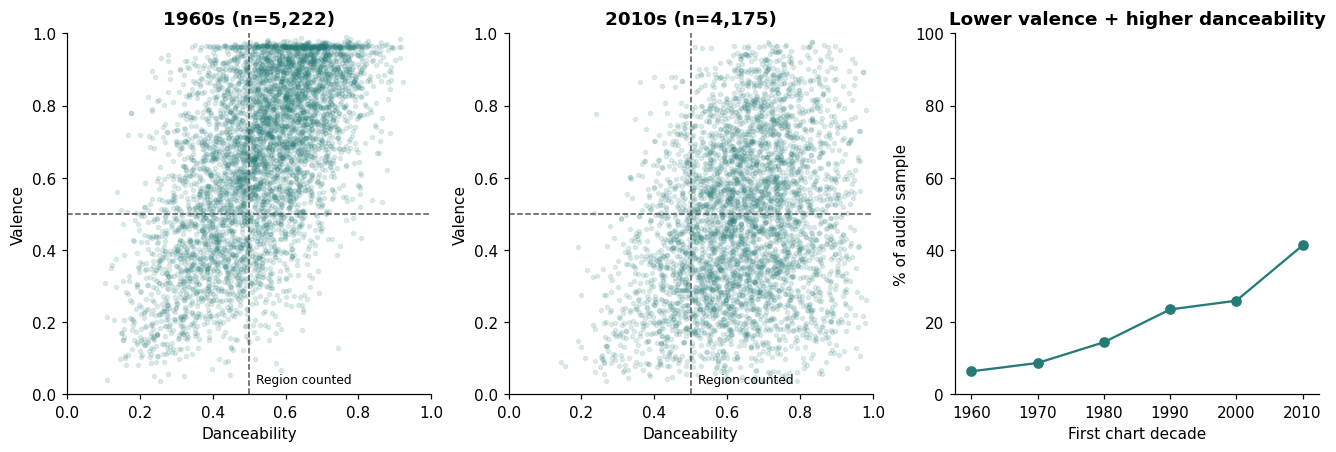

,Valence below,Danceability at least,1960s %,2010s %
0,0.4,0.4,7.0,35.3
1,0.4,0.5,2.9,28.7
2,0.4,0.6,0.8,19.5
3,0.5,0.4,13.3,49.7
4,0.5,0.5,6.3,41.2
5,0.5,0.6,1.9,28.6
6,0.6,0.4,22.2,64.9
7,0.6,0.5,11.8,54.9
8,0.6,0.6,4.3,38.7


In [38]:
audio['low_valence_danceable'] = (audio.valence < 0.5) & (audio.danceability >= 0.5)
joint_share = audio.groupby('decade').low_valence_danceable.mean() * 100
display(joint_share.round(1).rename('Share of audio sample (%)'))

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, decade in zip(axes[:2], [1960, 2010]):
    data = audio[audio.decade == decade]
    ax.scatter(data.danceability, data.valence, s=7, alpha=0.13, color='#267a78')
    ax.axvline(0.5, color='#555555', linestyle='--', linewidth=1)
    ax.axhline(0.5, color='#555555', linestyle='--', linewidth=1)
    ax.set(title=f'{decade}s (n={len(data):,})', xlabel='Danceability', ylabel='Valence', xlim=(0, 1), ylim=(0, 1))
    ax.text(0.52, 0.03, 'Region counted', fontsize=8)
axes[2].plot(joint_share.index, joint_share, marker='o', color='#267a78')
axes[2].set(title='Lower valence + higher danceability', xlabel='First chart decade', ylabel='% of audio sample', ylim=(0, 100))
plt.show()

# Change the two cutoffs separately, rather than only trying 0.5.
threshold_check = []
for valence_cutoff in [0.4, 0.5, 0.6]:
    for dance_cutoff in [0.4, 0.5, 0.6]:
        in_region = (audio.valence < valence_cutoff) & (audio.danceability >= dance_cutoff)
        shares = in_region.groupby(audio.decade).mean() * 100
        threshold_check.append([valence_cutoff, dance_cutoff, shares.loc[1960], shares.loc[2010]])
threshold_check = pd.DataFrame(threshold_check, columns=['Valence below', 'Danceability at least', '1960s %', '2010s %'])
display(threshold_check.round(1))


The share rises from 6.3% to 41.2%. It also rises under all nine cutoff combinations. That makes the result more convincing than a change that only appears at exactly 0.5.

Could a few prolific performers drive the result? We can give each performer credit the same weight within a decade and check. This is only approximate: collaboration credits such as “Artist A featuring Artist B” are separate performer strings in the source.


In [39]:
artist_share = audio.groupby(['decade', 'performer']).low_valence_danceable.mean()
artist_share = artist_share.groupby('decade').mean() * 100
joint_check = pd.DataFrame({'Each song counts equally': joint_share, 'Each performer credit counts equally': artist_share})
display(joint_check.round(1))


,Each song counts equally,Each performer credit counts equally
decade,,
1960,6.3,6.5
1970,8.6,9.3
1980,14.4,14.3
1990,23.5,21.4
2000,25.9,24.3
2010,41.2,42.4


### 4a. What does the existing mood feature add?

The supplied `mood` feature is **a category, not a numeric score**. Its four labels match a split at 0.5 on valence and energy. We verify this correspondence on every song with both measurements, including checking that missing measurements have missing categories. The feature script available with the earlier materials predates this table, so we validate the actual stored values rather than attribute an unverified formula to that script.

| Stored label | Valence | Energy | Descriptive label used below |
|---|---|---|---|
| happy/calm | ≥ 0.5 | < 0.5 | Higher valence / lower energy |
| happy/energetic | ≥ 0.5 | ≥ 0.5 | Higher valence / higher energy |
| sad/calm | < 0.5 | < 0.5 | Lower valence / lower energy |
| sad/energetic | < 0.5 | ≥ 0.5 | Lower valence / higher energy |

We avoid interpreting “happy” and “sad” as measured emotions. These are algorithmic audio descriptors, not measures of lyrical content or listeners' feelings. A mean of these category names would have no meaning; instead we examine category shares and the underlying continuous features. We keep the same complete-core-audio sample used in the main sound analysis.

,all_songs,with_mood,core_audio_songs,core_audio_coverage_pct
decade,,,,
1960,6850,5222,5222,76.2
1970,5299,4210,4210,79.4
1980,4113,3504,3504,85.2
1990,3423,2805,2805,81.9
2000,3418,3123,3123,91.4
2010,4446,4175,4175,93.9


mood,Higher valence / lower energy,Higher valence / higher energy,Lower valence / lower energy,Lower valence / higher energy
decade,,,,
1960,1386,2488,1133,215
1970,719,2458,726,307
1980,340,2303,434,427
1990,209,1626,394,576
2000,93,1743,271,1016
2010,135,1748,602,1690


mood,Higher valence / lower energy,Higher valence / higher energy,Lower valence / lower energy,Lower valence / higher energy
decade,,,,
1960,26.5,47.6,21.7,4.1
1970,17.1,58.4,17.2,7.3
1980,9.7,65.7,12.4,12.2
1990,7.5,58.0,14.0,20.5
2000,3.0,55.8,8.7,32.5
2010,3.2,41.9,14.4,40.5


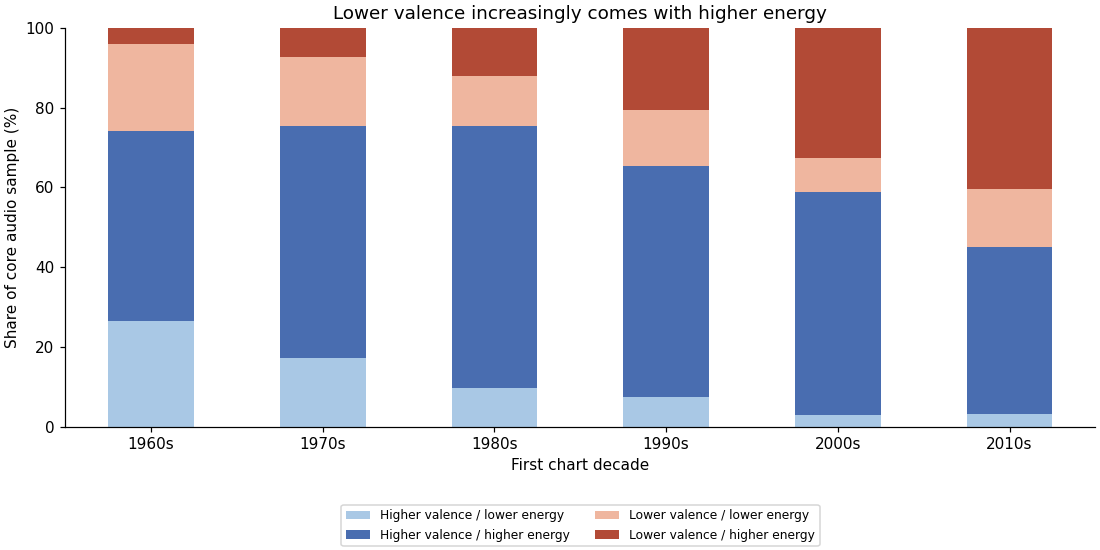

In [ ]:
has_mood_inputs = songs[['valence', 'energy']].notna().all(axis=1)
expected_mood = pd.Series(pd.NA, index=songs.index, dtype='string')
expected_mood.loc[has_mood_inputs] = (
    np.where(songs.loc[has_mood_inputs, 'valence'] >= 0.5, 'happy', 'sad')
    + pd.Series('/', index=songs.index[has_mood_inputs])
    + np.where(songs.loc[has_mood_inputs, 'energy'] >= 0.5, 'energetic', 'calm')
)
assert songs.mood.isna().equals(expected_mood.isna())
assert songs.loc[has_mood_inputs, 'mood'].eq(expected_mood.loc[has_mood_inputs]).all()

mood_order = ['happy/calm', 'happy/energetic', 'sad/calm', 'sad/energetic']
mood_labels = ['Higher valence / lower energy', 'Higher valence / higher energy',
               'Lower valence / lower energy', 'Lower valence / higher energy']
mood_counts = pd.crosstab(audio.decade, audio.mood).reindex(columns=mood_order)
mood_pct = mood_counts.div(mood_counts.sum(axis=1), axis=0) * 100
mood_coverage = sample.groupby('decade').agg(
    all_songs=('song_id', 'size'), with_mood=('mood', 'count'),
    core_audio_songs=('eda_core_complete', 'sum'),
)
mood_coverage['core_audio_coverage_pct'] = mood_coverage.core_audio_songs / mood_coverage.all_songs * 100
display(mood_coverage.round(1))
display(mood_counts.rename(columns=dict(zip(mood_order, mood_labels))))
display(mood_pct.rename(columns=dict(zip(mood_order, mood_labels))).round(1))

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
mood_pct.rename(columns=dict(zip(mood_order, mood_labels))).plot.bar(
    stacked=True, ax=ax, color=['#a9c8e5', '#496db0', '#efb69f', '#b24a36'])
ax.set(title='Lower valence increasingly comes with higher energy',
       xlabel='First chart decade', ylabel='Share of core audio sample (%)', ylim=(0, 100))
ax.set_xticklabels([f'{d}s' for d in mood_pct.index], rotation=0)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=8)
plt.show()

The lower-valence/higher-energy category rises from **4.1% in the 1960s to 40.5% in the 2010s**. The higher-valence/lower-energy category falls from **26.5% to 3.2%**. The higher-valence/higher-energy category first grows, peaking at **65.7% in the 1980s**, then falls to **41.9%** in the 2010s. These are changes in the observed audio sample, not estimates for songs with missing measurements.

This adds a useful distinction: lower valence does not necessarily come with lower energy. However, energy and danceability are different features, so this result complements rather than replaces our lower-valence/danceability comparison.

### Do the continuous scores and alternative cutoffs tell a similar story?

We plot annual means for valence, energy, and danceability on the same audio sample, then show their paired decade means. Means give a compact description, while the category shares above tell us how many individual songs fall in each region. A decade mean is not a typical individual song and cannot by itself establish a joint pattern.

,valence,energy,danceability
decade,,,
1960,0.662,0.516,0.531
1970,0.666,0.587,0.572
1980,0.660,0.656,0.627
1990,0.581,0.656,0.652
2000,0.550,0.716,0.623
2010,0.477,0.667,0.638


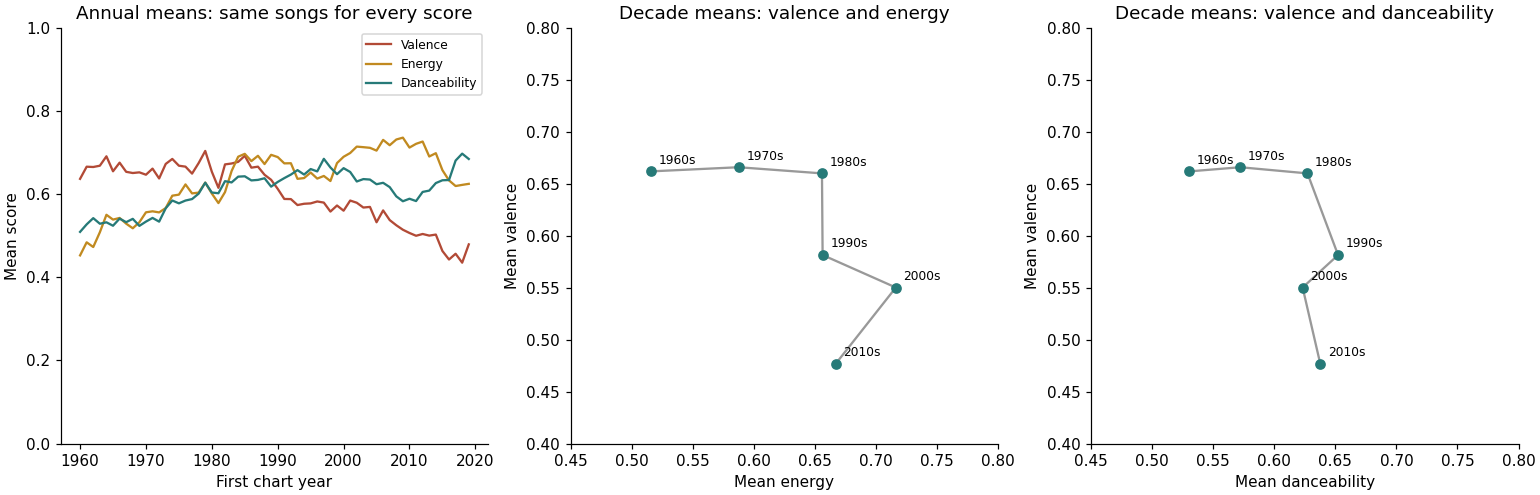

,Valence below,Energy at least,1960s %,2010s %,Change (pp)
0,0.4,0.4,4.1,34.0,30.0
1,0.4,0.5,1.8,27.6,25.8
2,0.4,0.6,0.9,19.3,18.4
3,0.5,0.4,8.7,48.4,39.7
4,0.5,0.5,4.1,40.5,36.4
5,0.5,0.6,2.2,29.5,27.2
6,0.6,0.4,15.6,63.1,47.4
7,0.6,0.5,8.6,54.4,45.8
8,0.6,0.6,4.7,41.6,37.0


,Lower valence / higher energy (%),Lower valence / higher danceability (%),Meets both definitions (%)
decade,,,
1960,4.1,6.3,1.4
1970,7.3,8.6,2.4
1980,12.2,14.4,7.4
1990,20.5,23.5,14.0
2000,32.5,25.9,19.9
2010,40.5,41.2,31.4


In [ ]:
mood_yearly_means = audio.groupby('first_observed_year')[['valence', 'energy', 'danceability']].mean()
mood_decade_means = audio.groupby('decade')[['valence', 'energy', 'danceability']].mean()
display(mood_decade_means.round(3))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
for feature, color in zip(['valence', 'energy', 'danceability'], ['#b24a36', '#c18a20', '#267a78']):
    axes[0].plot(mood_yearly_means.index, mood_yearly_means[feature], label=feature.capitalize(), color=color)
axes[0].set(title='Annual means: same songs for every score', xlabel='First chart year', ylabel='Mean score', ylim=(0, 1))
axes[0].legend(fontsize=8)
for ax, feature in zip(axes[1:], ['energy', 'danceability']):
    ax.plot(mood_decade_means[feature], mood_decade_means.valence, color='#999999', zorder=1)
    ax.scatter(mood_decade_means[feature], mood_decade_means.valence, color='#267a78', zorder=2)
    for decade, row in mood_decade_means.iterrows():
        ax.annotate(f'{decade}s', (row[feature], row.valence), xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax.set(title=f'Decade means: valence and {feature}', xlabel=f'Mean {feature}',
           ylabel='Mean valence', xlim=(0.45, 0.8), ylim=(0.4, 0.8))
plt.show()

# Check the two thresholds separately, using the same sample each time.
mood_threshold_rows = []
for valence_cutoff in [0.4, 0.5, 0.6]:
    for energy_cutoff in [0.4, 0.5, 0.6]:
        selected = (audio.valence < valence_cutoff) & (audio.energy >= energy_cutoff)
        share = selected.groupby(audio.decade).mean() * 100
        mood_threshold_rows.append({
            'Valence below': valence_cutoff, 'Energy at least': energy_cutoff,
            '1960s %': share.loc[1960], '2010s %': share.loc[2010],
            'Change (pp)': share.loc[2010] - share.loc[1960],
        })
mood_threshold_check = pd.DataFrame(mood_threshold_rows)
display(mood_threshold_check.round(1))

# Compare the energy-based and danceability-based regions directly.
energy_region = (audio.valence < 0.5) & (audio.energy >= 0.5)
dance_region = (audio.valence < 0.5) & (audio.danceability >= 0.5)
region_comparison = pd.DataFrame({
    'Lower valence / higher energy (%)': energy_region.groupby(audio.decade).mean() * 100,
    'Lower valence / higher danceability (%)': dance_region.groupby(audio.decade).mean() * 100,
    'Meets both definitions (%)': (energy_region & dance_region).groupby(audio.decade).mean() * 100,
})
display(region_comparison.round(1))

The continuous measures clarify the timing: mean valence is nearly unchanged across the 1960s–1980s and then falls, while energy rises earlier and peaks in the 2000s. The rise in the lower-valence/higher-energy share survives all nine threshold combinations shown above. Its exact size depends on the chosen cutoffs; 0.5 is a convenient division, not a validated emotional boundary.

The final table also shows that the energy-based and danceability-based regions overlap without being identical. We should not rename the energy-based category “danceable,” or treat a similar overall percentage as evidence that it selects the same songs.

**Implication:** the existing mood feature is useful for describing combinations of valence and energy. It does not introduce a new measurement beyond those inputs, but it does reveal joint structure that separate averages miss. We retain “lower valence, still danceable” as the lead because that claim is directly tested with danceability. The mood-category plot can support a broader point that lower-valence hits can still be energetic. Neither set of cutoffs recovers the missing audio or resolves matching uncertainty.

Equal weighting of performer credits gives a similar change: about 6.5% to 42.4%. The result is not confined to a few performers with many charting songs.

**Story option:** lower-valence music became more common without losing danceability. The paired scatterplots and share-over-time line could lead the report. We still need to check whether this is shared across genres and how much the missing audio could matter.

## 5. Are top-10 hits more danceable?

We compare songs that reached the top 10 with other Hot 100 songs in the same decade. These are all charting songs, so the result cannot tell us what makes an arbitrary released song successful. Peak rank is observed through the end of the dataset and may include later chart runs.


size  median
decade top10              
1960   False  4264   0.534
       True    958   0.556
1970   False  3360   0.575
       True    850   0.610
1980   False  2609   0.629
       True    895   0.652
1990   False  2231   0.661
       True    574   0.668
2000   False  2575   0.610
       True    548   0.688
2010   False  3694   0.636
       True    481   0.682

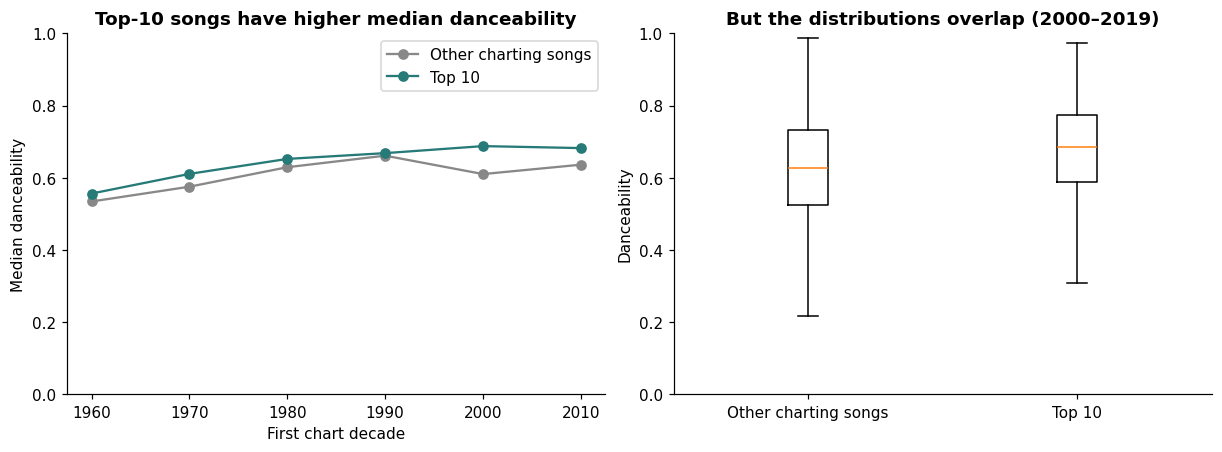

In [40]:
top10_stats = audio.groupby(['decade', 'top10']).danceability.agg(['size', 'median'])
display(top10_stats.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for top10, label, color in [(False, 'Other charting songs', '#888888'), (True, 'Top 10', '#267a78')]:
    data = top10_stats.xs(top10, level='top10')
    axes[0].plot(data.index, data['median'], marker='o', label=label, color=color)
axes[0].set(title='Top-10 songs have higher median danceability', xlabel='First chart decade', ylabel='Median danceability', ylim=(0, 1))
axes[0].legend()

recent_audio = audio[audio.decade >= 2000]
axes[1].boxplot([recent_audio.loc[~recent_audio.top10, 'danceability'],
                 recent_audio.loc[recent_audio.top10, 'danceability']], showfliers=False)
axes[1].set_xticks([1, 2], ['Other charting songs', 'Top 10'])
axes[1].set(title='But the distributions overlap (2000–2019)', ylabel='Danceability', ylim=(0, 1))
plt.show()


Top-10 songs have higher median danceability in each decade, but the distributions overlap substantially. A genre imbalance could contribute to the gap. At this point we have several patterns to explain, so we turn to the genre labels before deciding which comparisons belong in the report.

## 6. Looking inside genres

### Are the labels usable?

The buckets are made from Spotify artist tags using keyword votes. They are our categories, not Billboard's official classification of each song. We want to separate missing tags, debatable bucket rules, and tags that appear to belong to a different artist.


In [41]:
# A review cue, not an automatic rule for deleting songs.
early_rap = songs[(songs.first_observed_year < 1980) & (songs.genre_bucket == 'rap')]
print('Songs in the rap bucket before 1980:', len(early_rap))

raw_audio = pd.read_csv(root / 'data' / 'raw' / 'audio_features.csv')
albums = raw_audio[['song_id', 'spotify_track_id', 'spotify_track_album']]
albums = albums.drop_duplicates(['song_id', 'spotify_track_id'])

examples = songs[songs.song.isin(['Cara, Mia', 'Bell Bottom Blues', 'Back To The Hop'])]
examples = examples.merge(albums, on=['song_id', 'spotify_track_id'], how='left', validate='m:1')
with pd.option_context('display.max_colwidth', 110):
    display(examples[['song', 'performer', 'spotify_genre', 'genre_bucket', 'spotify_track_album']])

# A few examples across the main buckets, including recent songs.
review_sample = sample[sample.genre_bucket.isin(main_genres)]
review_sample = review_sample.groupby('genre_bucket').sample(n=3, random_state=510)
with pd.option_context('display.max_colwidth', 90):
    display(review_sample[['song', 'performer', 'first_observed_year', 'spotify_genre', 'genre_bucket']])


Songs in the rap bucket before 1980: 76


,song,performer,spotify_genre,genre_bucket,spotify_track_album
0,Back To The Hop,Danny & The Juniors,"['alternative hip hop', 'detroit hip hop', 'escape room', 'hip hop', 'rap', 'southern hip hop', 'undergrou...",rap,The Complete Releases 1957-62
1,Bell Bottom Blues,Derek & The Dominos,"['christian hip hop', 'christian trap']",rap,Layla And Other Assorted Love Songs (40th Anniversary / 2010 Remastered)
2,Bell Bottom Blues,Eric Clapton,"['album rock', 'blues rock', 'classic rock', 'electric blues', 'mellow gold', 'rock', 'soft rock']",rock,Eric Clapton's Rainbow Concert
3,"Cara, Mia",Jay & The Americans,"['east coast hip hop', 'hip hop', 'pop rap', 'rap', 'southern hip hop']",rap,Come A Little Bit Closer: The Best Of Jay & The Americans


,song,performer,first_observed_year,spotify_genre,genre_bucket
3515,C.b. Savage,Rod Hart,1976,['truck-driving country'],country
4501,Confession,Florida Georgia Line,2016,"['contemporary country', 'country', 'country pop', 'country road', 'modern country rock']",country
19535,Raise 'Em Up,Keith Urban Featuring Eric Church,2015,"['australian country', 'contemporary country', 'country', 'country road']",country
2735,"Billy, Don't Be A Hero",Bo Donaldson And The Heywoods,1974,['bubblegum pop'],pop
9277,Heart Attack,Trey Songz,2012,"['dance pop', 'pop', 'pop rap', 'r&b', 'trap', 'urban contemporary']",pop
9739,High School,Nicki Minaj Featuring Lil Wayne,2013,"['dance pop', 'hip pop', 'pop', 'pop rap', 'post-teen pop', 'queens hip hop', 'rap']",pop
11487,I Want Your Love,Chic,1979,"['disco', 'disco house', 'funk', 'motown', 'post-disco', 'quiet storm', 'soul']",r&b
10868,I Got What I Wanted,Brook Benton,1963,"['adult standards', 'brill building pop', 'motown', 'rhythm and blues', 'rock-and-roll...",r&b
25239,These Hands (Small But Mighty),Bobby Bland,1965,"['blues', 'electric blues', 'soul', 'soul blues', 'southern soul']",r&b
8632,Goodbye To My Homies,"Master P Featuring Silkk The Shocker, Sons Of Funk And Mo B. Dick",1998,"['deep southern trap', 'dirty south rap', 'gangster rap', 'hip hop', 'new orleans rap'...",rap


There are 76 pre-1980 songs assigned to rap. That is a useful flag, not proof that every one is wrong. The tags on “Cara, Mia” and the Derek & The Dominos version of “Bell Bottom Blues” look particularly suspicious. Their album names look plausible, which is a reminder that genre metadata can be wrong even when the recording match looks reasonable.

The small sample above is a starting point for review, not a validation of all the tags. We will keep the original labels and use the large buckets for exploratory comparisons. We will not silently reclassify songs based on what we think they should be. If a genre result becomes central to the report, we need to verify examples from the relevant artists and periods and document any changes.

### How did the genre mix change?

We calculate genre composition from **all songs in the main period**, including those without audio. That avoids treating the available audio sample as the complete chart population.


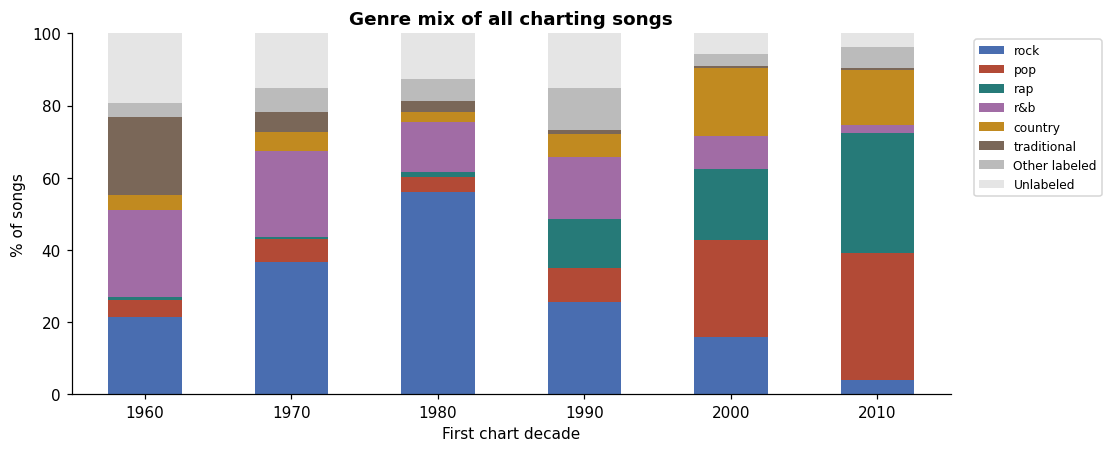

In [42]:
all_mix = pd.crosstab(sample.decade, sample.genre_bucket, normalize='index') * 100
plot_mix = all_mix[['rock', 'pop', 'rap', 'r&b', 'country', 'traditional']].copy()
plot_mix['Other labeled'] = all_mix[['dance', 'latin', 'christian', 'other']].sum(axis=1)
plot_mix['Unlabeled'] = all_mix.unlabeled

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
plot_mix.plot.bar(stacked=True, ax=ax, color=['#496db0', '#b24a36', '#267a78', '#a16ca5', '#c18a20', '#7a6758', '#bbbbbb', '#e5e5e5'])
ax.set(title='Genre mix of all charting songs', xlabel='First chart decade', ylabel='% of songs', ylim=(0, 100))
ax.tick_params(axis='x', rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.show()


The assigned genre mix changes substantially: rock is much more prominent in earlier decades, while pop and rap make up much larger shares in the 2010s. This gives us an alternative explanation for the overall audio trends: the chart may have filled up with different types of music.

### Does the valence/danceability pattern appear within genres?

We compare a few large buckets and leave gaps where there are fewer than 100 songs. This is a display choice, not a guarantee that larger groups are representative.


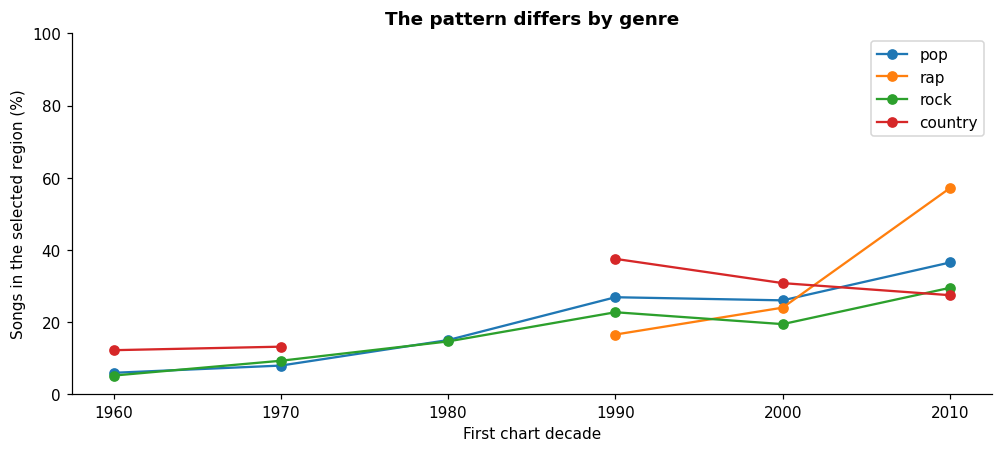

,,size,mean
decade,genre_bucket,,
1960,pop,287,0.059
1970,pop,290,0.079
1980,pop,160,0.150
1990,pop,294,0.269
2000,pop,869,0.260
2010,pop,1515,0.365
1960,rap,34,0.029
1970,rap,20,0.050
1980,rap,53,0.113


In [43]:
genre_joint = audio.groupby(['decade', 'genre_bucket']).low_valence_danceable.agg(['size', 'mean'])
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
for genre in ['pop', 'rap', 'rock', 'country']:
    data = genre_joint.xs(genre, level='genre_bucket')
    values = (data['mean'] * 100).where(data['size'] >= 100)
    ax.plot(data.index, values, marker='o', label=genre)
ax.set(title='The pattern differs by genre', xlabel='First chart decade', ylabel='Songs in the selected region (%)', ylim=(0, 100))
ax.legend()
plt.show()
display(genre_joint.loc[(slice(None), ['pop', 'rap', 'rock', 'country']), :].round(3))


Among songs currently tagged as rap, the lower-valence/higher-danceability share rises from about 16.5% in the 1990s to 57.1% in the 2010s. Pop also rises, from 26.9% to 36.5%, while country falls from its 1990s level. The overall pattern is not shared equally across genres.

This could add depth to the main story, but the source tags make the exact genre comparisons provisional.

### Is falling valence just a change in genre mix?
For the fixed-mix comparison we use pop, rock, rap, R&B, and country from 1980 onward. Each has at least 50 audio observations in each decade of this window. The restriction avoids extremely sparse early rap groups, but it also leaves out some songs, so we report the included share.

This calculation uses **means**, because a weighted average of genre medians would not reproduce the overall median. We calculate each genre's mean valence, then combine those means using the 1980s genre shares in every decade. This is a descriptive comparison, not a causal estimate of genre's effect.


genre_bucket,country,pop,r&b,rap,rock
decade,,,,,
1980,98,160,523,53,2140
1990,208,294,517,369,797
2000,627,869,297,617,515
2010,667,1515,87,1397,173


Share of the audio sample included:


decade
1980    84.9
1990    77.9
2000    93.7
2010    92.0
dtype: float64

,Observed genre mix,1980s genre mix held fixed
decade,,
1980,0.656,0.656
1990,0.565,0.550
2000,0.547,0.503
2010,0.476,0.453


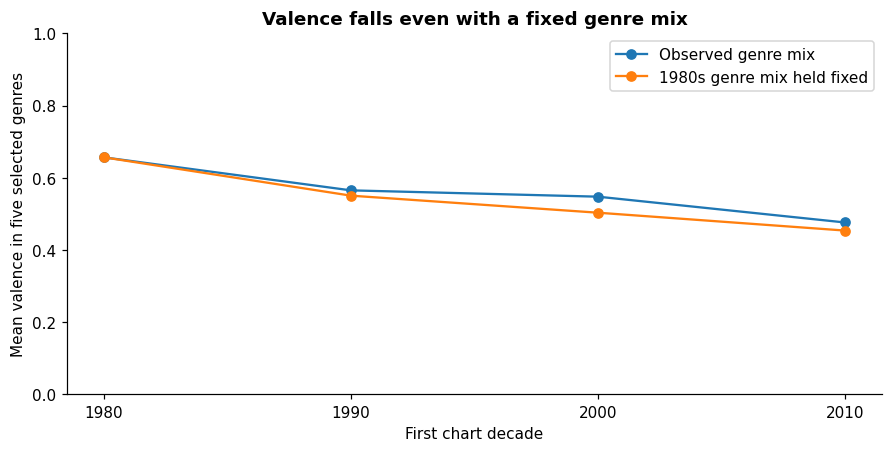

In [44]:
genre_sample = audio[(audio.decade >= 1980) & audio.genre_bucket.isin(main_genres)]
counts = pd.crosstab(genre_sample.decade, genre_sample.genre_bucket)
assert (counts >= 50).all().all()
display(counts)

included_share = genre_sample.groupby('decade').size() / audio[audio.decade >= 1980].groupby('decade').size()
print('Share of the audio sample included:')
display((included_share * 100).round(1))

genre_means = genre_sample.groupby(['decade', 'genre_bucket']).valence.mean().unstack()
genre_weights = counts.div(counts.sum(axis=1), axis=0)
fixed_weights = genre_weights.loc[1980]
fixed_mix = genre_means.mul(fixed_weights, axis=1).sum(axis=1)
observed_mix = genre_sample.groupby('decade').valence.mean()

valence_mix_check = pd.DataFrame({'Observed genre mix': observed_mix, '1980s genre mix held fixed': fixed_mix})
display(valence_mix_check.round(3))
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
valence_mix_check.plot(ax=ax, marker='o')
ax.set(title='Valence falls even with a fixed genre mix', xlabel='First chart decade', ylabel='Mean valence in five selected genres', ylim=(0, 1), xticks=[1980, 1990, 2000, 2010])
plt.show()


Across these five buckets, mean valence falls from 0.656 to 0.476. Holding the genre mix at its 1980s proportions gives 0.453 in the 2010s, so the decline does not disappear. A change in the proportions of these five genres is not enough to explain the pattern in this sample.

This does **not** mean genre has no role. Artists and subgenres change inside each bucket, the labels may be wrong, and these groups cover different shares of the audio sample in each decade. It also does not explain the missing songs. Still, it gives us a stronger potential genre story than simply showing rock declining and rap increasing.

**Story option:** “More than a change in genre.” Pair the genre-mix bars with the fixed-mix valence comparison. We would only make this a main section after a more targeted check of the relevant genre tags.

### Do length and acousticness also change within genres?

We use the same buckets to see whether our other leads survive a closer look. The duration comparison starts in the 1990s, when the overall median was highest. For acousticness we retain the earlier decades because that is when the largest overall decline occurred.


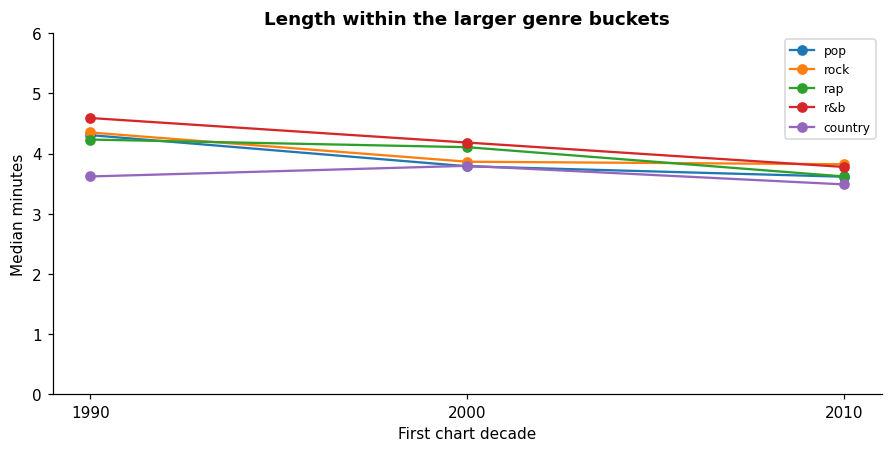

,,count,median
decade,genre_bucket,,
1990,pop,294,4.308
2000,pop,869,3.790
2010,pop,1515,3.616
1990,rock,797,4.352
2000,rock,515,3.866
2010,rock,173,3.823
1990,rap,372,4.234
2000,rap,631,4.107
2010,rap,1410,3.620


In [45]:
genre_length = recent_lengths.groupby(['decade', 'genre_bucket']).duration_minutes.agg(['count', 'median'])
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for genre in main_genres:
    data = genre_length.xs(genre, level='genre_bucket')
    ax.plot(data.index, data['median'].where(data['count'] >= 50), marker='o', label=genre)
ax.set(title='Length within the larger genre buckets', xlabel='First chart decade',
       ylabel='Median minutes', ylim=(0, 6), xticks=[1990, 2000, 2010])
ax.legend(fontsize=8)
plt.show()
display(genre_length.loc[(slice(None), main_genres), :].round(3))


Pop, rap, rock, and R&B all have lower median duration in the 2010s than the 1990s under the current mapping. Country changes less over this comparison. Genre turnover alone is therefore not a sufficient description of the duration pattern in these groups.


,count,median,mean,Change from previous decade
decade,,,,
1960,5222,0.579,0.527,NaN
1970,4210,0.282,0.337,-0.298
1980,3504,0.124,0.201,-0.157
1990,2805,0.082,0.170,-0.043
2000,3123,0.072,0.150,-0.010
2010,4175,0.083,0.184,0.011


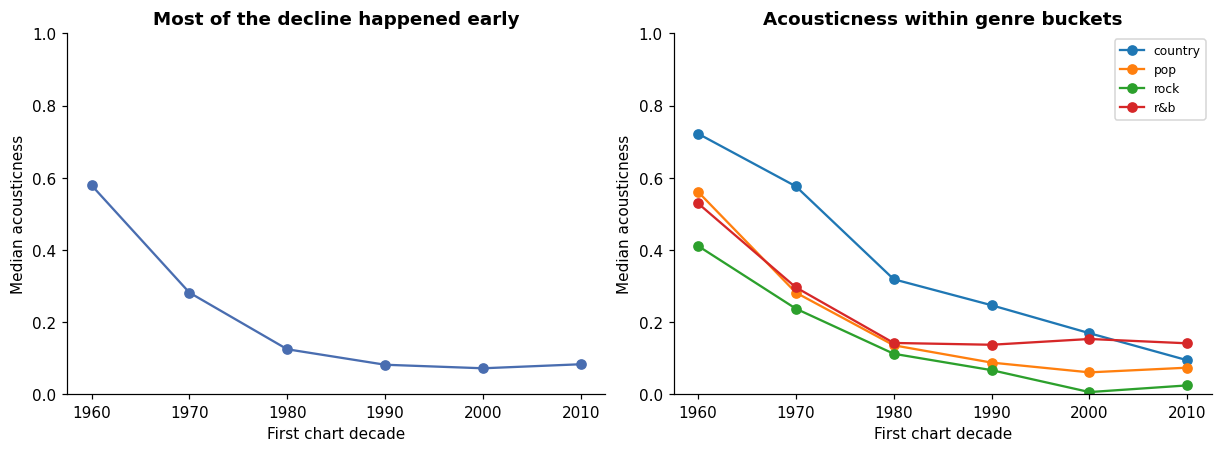

,,size,median
decade,genre_bucket,,
1960,country,246,0.722
1970,country,243,0.576
1980,country,98,0.318
1990,country,208,0.246
2000,country,627,0.169
2010,country,667,0.094
1960,pop,287,0.561
1970,pop,290,0.282
1980,pop,160,0.136


In [46]:
acoustic_stats = audio.groupby('decade').acousticness.agg(['count', 'median', 'mean'])
acoustic_stats['Change from previous decade'] = acoustic_stats['median'].diff()
display(acoustic_stats.round(3))

acoustic_by_genre = audio.groupby(['decade', 'genre_bucket']).acousticness.agg(['size', 'median'])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(acoustic_stats.index, acoustic_stats['median'], marker='o', color='#496db0')
axes[0].set(title='Most of the decline happened early', xlabel='First chart decade', ylabel='Median acousticness', ylim=(0, 1))
for genre in ['country', 'pop', 'rock', 'r&b']:
    data = acoustic_by_genre.xs(genre, level='genre_bucket')
    axes[1].plot(data.index, data['median'].where(data['size'] >= 50), marker='o', label=genre)
axes[1].set(title='Acousticness within genre buckets', xlabel='First chart decade', ylabel='Median acousticness', ylim=(0, 1))
axes[1].legend(fontsize=8)
plt.show()
display(acoustic_by_genre.loc[(slice(None), ['country', 'pop', 'rock', 'r&b']), :].round(3))


Median acousticness falls from 0.579 in the 1960s to 0.124 in the 1980s, then changes much less. There is a small rise from the 2000s to the 2010s. The pattern is not a continuous march toward lower acousticness.

Country is an interesting follow-up: the median in that bucket falls from 0.722 to 0.094. Its audio coverage is relatively high, including about 87% in the 1960s and 98% in the 2010s. Pop and rock also fall within their buckets. High coverage does not validate the tags or eliminate recording-version issues, but it makes these comparisons worth investigating.

**Story option:** “The acoustic shift happened long before the latest streaming era.” The overall line would establish timing; the country/pop/rock lines could show that it was not simply a change in genre proportions. We would avoid explanations about recording technology unless we have sources for them.

### Does the top-10 danceability gap survive within genres?

We check the 2000s and 2010s separately within pop, rap, rock, and R&B, showing only comparisons with at least 30 songs in each rank group. This leaves out some small groups rather than treating their medians as equally reliable.


Other songs n  Top 10 n  Other songs median  \
genre_bucket decade                                                
pop          2000              615       254               0.631   
             2010             1220       295               0.626   
r&b          2000              249        48               0.687   
             2010               79         8               0.648   
rap          2000              471       146               0.739   
             2010             1272       125               0.729   
rock         2000              445        70               0.499   
             2010              157        16               0.548   

                     Top 10 median  Difference  
genre_bucket decade                             
pop          2000            0.702       0.071  
             2010            0.665       0.039  
r&b          2000            0.700       0.013  
             2010            0.652       0.004  
rap          2000            0.726      -0.013  
             2010            0.746       0.017  
rock         2000            0.524       0.025  
             2010            0.665       0.117

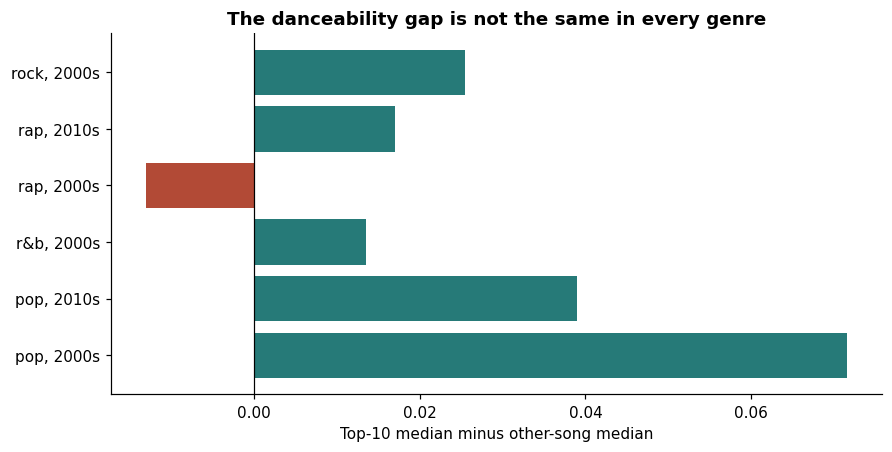

In [47]:
rank_genre = recent_audio[recent_audio.genre_bucket.isin(['pop', 'rap', 'rock', 'r&b'])]
rank_genre = rank_genre.groupby(['genre_bucket', 'decade', 'top10']).danceability.agg(['size', 'median'])
counts = rank_genre['size'].unstack('top10')
values = rank_genre['median'].unstack('top10')
rank_genre_check = pd.DataFrame({
    'Other songs n': counts[False],
    'Top 10 n': counts[True],
    'Other songs median': values[False],
    'Top 10 median': values[True],
    'Difference': values[True] - values[False],
})
display(rank_genre_check.round(3))

usable = rank_genre_check[(rank_genre_check['Other songs n'] >= 30) & (rank_genre_check['Top 10 n'] >= 30)]
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
labels = [f'{genre}, {decade}s' for genre, decade in usable.index]
ax.barh(labels, usable.Difference, color=['#267a78' if x >= 0 else '#b24a36' for x in usable.Difference])
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='The danceability gap is not the same in every genre', xlabel='Top-10 median minus other-song median')
plt.show()


The pop gap remains in both decades: about 0.071 in the 2000s and 0.039 in the 2010s. Rap reverses direction, from about −0.013 to +0.017. That is much less convincing evidence of a consistent within-genre difference. Pooling 2000–2019 gives identical rap medians, which would hide this small reversal.

**Story option:** “Danceability helps describe the biggest pop hits, but it is not a universal formula.” The genre-by-decade difference chart is more interesting than just repeating the overall top-10 comparison. We would use 'associated with' rather than 'helps a song succeed,' because this analysis does not separate genre, artist, promotion, release timing, or other influences.

## 7. Which songs are missing audio?

The genre comparisons suggest that the broad trends are not only a change in genre proportions. But all of the sound comparisons still leave out songs without audio. We now look at coverage by decade, chart success, and genre to see which conclusions may be affected.


,songs,audio_available,audio_coverage,genre_coverage
decade,,,,
1960,6850,5222,0.762,0.806
1970,5299,4210,0.794,0.848
1980,4113,3504,0.852,0.874
1990,3423,2805,0.819,0.847
2000,3418,3123,0.914,0.944
2010,4446,4175,0.939,0.963


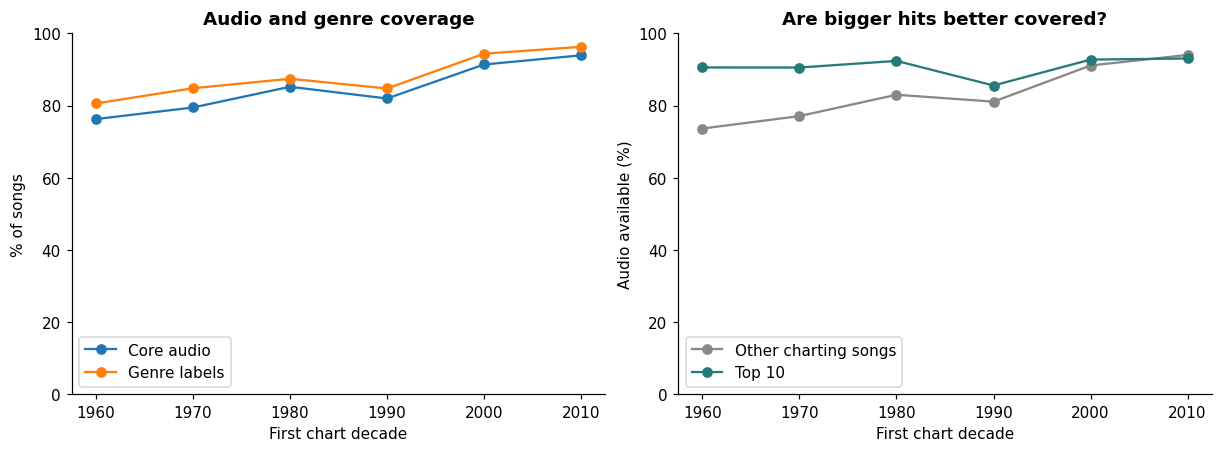

In [48]:
coverage = sample.groupby('decade').agg(
    songs=('song_id', 'size'),
    audio_available=('eda_core_complete', 'sum'),
    audio_coverage=('eda_core_complete', 'mean'),
    genre_coverage=('has_genre', 'mean'),
)
display(coverage.round(3))

rank_coverage = sample.groupby(['decade', 'top10']).eda_core_complete.mean() * 100
rank_coverage = rank_coverage.unstack()
rank_coverage.columns = ['Other charting songs', 'Top 10']

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
(coverage[['audio_coverage', 'genre_coverage']] * 100).plot(ax=axes[0], marker='o')
axes[0].set(title='Audio and genre coverage', ylabel='% of songs', xlabel='First chart decade', ylim=(0, 100))
axes[0].legend(['Core audio', 'Genre labels'])
rank_coverage.plot(ax=axes[1], marker='o', color=['#888888', '#267a78'])
axes[1].set(title='Are bigger hits better covered?', ylabel='Audio available (%)', xlabel='First chart decade', ylim=(0, 100))
plt.show()


Audio coverage improves from 76% in the 1960s to 94% in the 2010s. In the 1960s it is about 91% for top-10 hits but only 74% for other charting songs. The early audio sample therefore leans toward more successful records. We also compare top-10-only trends in the final counting check.

Genre coverage is higher than audio coverage, so genre can tell us something about the missing songs. It cannot tell us what those songs sound like.


,songs,with_audio,audio_coverage,missing_audio,share_of_missing
genre_bucket,,,,,
unlabeled,3537,1462,0.413,2075,0.460
other,693,530,0.765,163,0.036
traditional,1998,1588,0.795,410,0.091
christian,67,56,0.836,11,0.002
r&b,4502,3980,0.884,522,0.116
dance,702,628,0.895,74,0.016
latin,144,130,0.903,14,0.003
rap,2732,2490,0.911,242,0.054
rock,7293,6671,0.915,622,0.138


Missing audio: 4,510
Missing audio but still has genre labels: 2,435


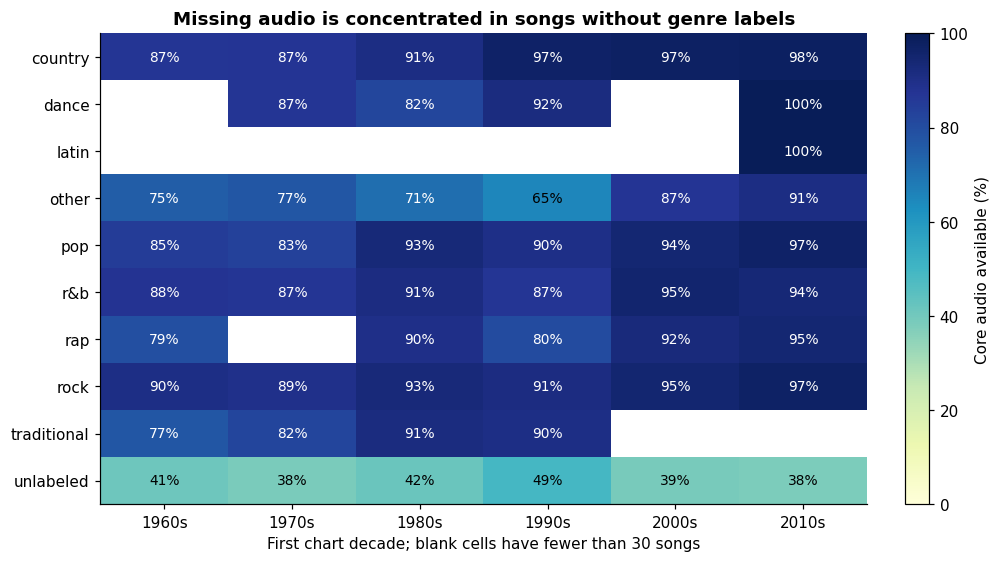

In [49]:
genre_coverage = sample.groupby('genre_bucket').agg(
    songs=('song_id', 'size'),
    with_audio=('eda_core_complete', 'sum'),
    audio_coverage=('eda_core_complete', 'mean'),
)
genre_coverage['missing_audio'] = genre_coverage.songs - genre_coverage.with_audio
genre_coverage['share_of_missing'] = genre_coverage.missing_audio / genre_coverage.missing_audio.sum()
display(genre_coverage.sort_values('audio_coverage').round(3))

missing = sample[~sample.eda_core_complete]
print(f'Missing audio: {len(missing):,}')
print(f'Missing audio but still has genre labels: {missing.has_genre.sum():,}')

# Compare coverage within decades as well as across the whole period.
coverage_by_genre = sample.groupby(['genre_bucket', 'decade']).eda_core_complete.mean().unstack() * 100
genre_counts = pd.crosstab(sample.genre_bucket, sample.decade)
coverage_plot = coverage_by_genre.where(genre_counts >= 30).dropna(how='all')

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
im = ax.imshow(coverage_plot, vmin=0, vmax=100, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(6), [f'{d}s' for d in decades])
ax.set_yticks(range(len(coverage_plot)), coverage_plot.index)
for row in range(len(coverage_plot)):
    for col in range(6):
        value = coverage_plot.iloc[row, col]
        if pd.notna(value):
            ax.text(col, row, f'{value:.0f}%', ha='center', va='center',
                    color='white' if value >= 70 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, label='Core audio available (%)')
ax.set_title('Missing audio is concentrated in songs without genre labels')
ax.set_xlabel('First chart decade; blank cells have fewer than 30 songs')
plt.show()


Of the 4,510 songs missing audio, 2,435 still have genre labels. Songs without genre labels have only about 41% audio coverage overall, compared with 93% for the pop bucket and 94% for country. The gap for unlabeled songs appears in every decade, so it is not just a result of older songs being more common in that group.

This suggests a possible **data story**: which hits survive in a dataset assembled from a streaming catalog? We can show the coverage gap, but cannot say whether catalog availability, matching problems, or another source issue caused it. The genre labels are useful for describing missingness even though they need more checking before making precise claims about musical history.

We also want to know how much filtering to available audio changes the apparent genre mix.


genre_bucket,rock,r&b,pop,country,unlabeled
decade,,,,,
1960,4.0,3.6,0.6,0.6,-9.0
1970,4.5,2.2,0.3,0.5,-7.9
1980,5.1,1.0,0.4,0.2,-6.5
1990,2.9,1.1,1.0,1.1,-6.2
2000,0.6,0.4,0.9,1.2,-3.2
2010,0.1,-0.0,1.1,0.6,-2.2


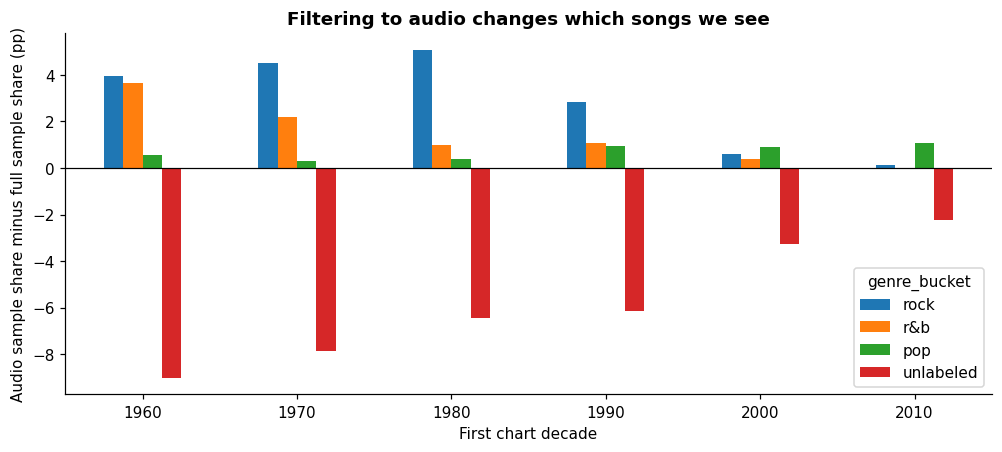

In [50]:
audio_mix = pd.crosstab(audio.decade, audio.genre_bucket, normalize='index') * 100
mix_difference = audio_mix - all_mix

# Positive values mean the category is more common in the audio sample.
display(mix_difference[['rock', 'r&b', 'pop', 'country', 'unlabeled']].round(1))

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
mix_difference[['rock', 'r&b', 'pop', 'unlabeled']].plot.bar(ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set(title='Filtering to audio changes which songs we see',
       ylabel='Audio sample share minus full sample share (pp)', xlabel='First chart decade')
ax.tick_params(axis='x', rotation=0)
plt.show()


In the 1960s, unlabeled songs lose about 9 percentage points of representation after the audio filter, while rock gains about 4 points. This is a reason to calculate **genre composition from all charting songs**, not just the audio sample. The difference is smaller in recent decades.

For the report, the coverage heatmap could work as a methods figure or as part of a story about the limits of music archives. We would keep it near the historical comparisons rather than bury all of the missing-data discussion at the end.

## 8. Could the missing audio change the overall trends?

### Use genre and decade to build a plausible scenario

We have genre labels for 2,435 of the 4,510 songs missing core audio. Instead of only noting that those songs are absent, we can ask what the trend would look like if their average scores resembled the observed songs in the same genre and decade.

This assumes that the missing and observed songs are similar **within those groups**. It is an assumption to test, not something established by the data. The suspicious genre tags also carry through to these estimates.

We estimate missing scores using the genre–decade mean where at least 20 measurements are available. For smaller groups, or songs without genre labels, we use the overall observed decade mean. That fallback is a weaker assumption, and we count how often it is used. We keep the original scores untouched and use separate tables for these scenarios.

This check uses **means**. Filling gaps with group averages would flatten the distributions, so we do not use these estimates to recalculate medians or the low-valence/high-danceability share.


,Missing scores,Use genre and decade,Small-group fallback,No-label fallback
Feature,,,,
valence,4510,2407,28,2075
danceability,4510,2407,28,2075
energy,4510,2407,28,2075
acousticness,4510,2407,28,2075


,Observed 1960s,Scenario 1960s,Observed 2010s,Scenario 2010s
valence,0.662,0.659,0.477,0.476
danceability,0.531,0.530,0.638,0.638
energy,0.516,0.513,0.667,0.667
acousticness,0.527,0.531,0.184,0.184


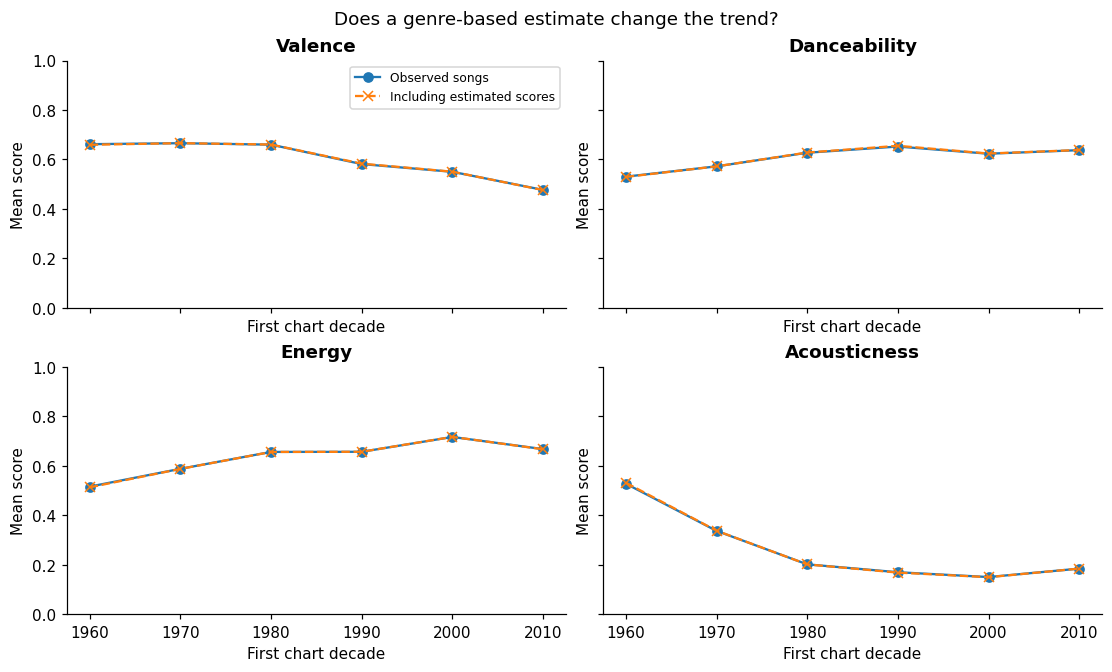

In [51]:
observed_means = sample.groupby('decade')[scores].mean()
group_means = sample.groupby(['decade', 'genre_bucket'])[scores].transform('mean')
group_counts = sample.groupby(['decade', 'genre_bucket'])[scores].transform('count')
decade_means = sample.groupby('decade')[scores].transform('mean')

estimates = pd.DataFrame(index=sample.index)
estimate_counts = []
for score in scores:
    missing_score = sample[score].isna()
    use_genre = sample.has_genre & (group_counts[score] >= 20)
    estimates[score] = group_means[score].where(use_genre, decade_means[score])
    estimate_counts.append({
        'Feature': score,
        'Missing scores': missing_score.sum(),
        'Use genre and decade': (missing_score & use_genre).sum(),
        'Small-group fallback': (missing_score & sample.has_genre & ~use_genre).sum(),
        'No-label fallback': (missing_score & ~sample.has_genre).sum(),
    })

assert estimates.notna().all().all()
assert sample[scores].stack().between(0, 1).all()
estimated_scores = sample[scores].fillna(estimates)
scenario_means = estimated_scores.groupby(sample.decade).mean()
display(pd.DataFrame(estimate_counts).set_index('Feature'))

endpoint_comparison = pd.DataFrame({
    'Observed 1960s': observed_means.loc[1960],
    'Scenario 1960s': scenario_means.loc[1960],
    'Observed 2010s': observed_means.loc[2010],
    'Scenario 2010s': scenario_means.loc[2010],
})
display(endpoint_comparison.round(3))

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True, constrained_layout=True)
for ax, score in zip(axes.flat, scores):
    ax.plot(observed_means.index, observed_means[score], marker='o', label='Observed songs')
    ax.plot(scenario_means.index, scenario_means[score], marker='x', linestyle='--', label='Including estimated scores')
    ax.set(title=score.capitalize(), xlabel='First chart decade', ylabel='Mean score', ylim=(0, 1))
axes[0, 0].legend(fontsize=8)
fig.suptitle('Does a genre-based estimate change the trend?')
plt.show()


The observed and estimated lines are very close. Under this scenario, the available genre information does not change the direction or size of the average trends very much. This is more specific than saying that missing audio is a limitation, but it is not proof that the missing songs actually resemble their group averages.

### What if missing songs differ from their group?

We also shift the estimated scores by up to 0.10 at the two endpoints. In one scenario, the missing songs in each decade are shifted in the direction that **weakens** the observed 1960s-to-2010s change; in another, they are shifted to strengthen it. The adjustments apply to all missing scores, including the fallback estimates. Scores stay between 0 and 1.

These are deliberately chosen stress tests, not confidence intervals or estimated probabilities. They test the endpoint comparison, not the detailed shape of every intervening decade.


In [52]:
scenario_changes = []
for score in scores:
    observed_change = observed_means.loc[2010, score] - observed_means.loc[1960, score]
    direction = np.sign(observed_change)
    row = {
        'Feature': score,
        'Observed change': observed_change,
        'Group-estimate change': scenario_means.loc[2010, score] - scenario_means.loc[1960, score],
    }
    for scenario, shift in [('Weaken trend', 0.10), ('Strengthen trend', -0.10)]:
        shifted_estimates = estimates[score].copy()
        early = sample.decade == 1960
        late = sample.decade == 2010
        shifted_estimates.loc[early] += shift * direction
        shifted_estimates.loc[late] -= shift * direction
        shifted_estimates = shifted_estimates.clip(0, 1)

        filled = sample[score].fillna(shifted_estimates)
        means = filled.groupby(sample.decade).mean()
        row[scenario] = means.loc[2010] - means.loc[1960]
    scenario_changes.append(row)

display(pd.DataFrame(scenario_changes).set_index('Feature').round(3))


,Observed change,Group-estimate change,Weaken trend,Strengthen trend
Feature,,,,
valence,-0.185,-0.183,-0.153,-0.213
danceability,0.107,0.109,0.079,0.139
energy,0.152,0.154,0.124,0.184
acousticness,-0.343,-0.347,-0.317,-0.377


The directions survive these 0.10 stress tests. We should describe that as robustness to the stated scenarios, not robustness to any possible missing-data pattern. In particular, using the overall decade average for unlabeled songs could still miss a larger difference.

### What could happen without any assumptions about the missing scores?

All four scores lie between 0 and 1. We can find the lowest and highest possible **full-sample mean** in each decade by assigning every missing value 0 or 1. To get the smallest possible endpoint change, we subtract the highest 1960s mean from the lowest 2010s mean; for the largest possible change, we do the reverse.

These bounds do not use genre estimates. They are intentionally extreme and cover every missing song, including those without labels.


In [53]:
lower_means = sample[scores].fillna(0).groupby(sample.decade).mean()
upper_means = sample[scores].fillna(1).groupby(sample.decade).mean()
bounds = pd.DataFrame({
    'Observed change': observed_means.loc[2010] - observed_means.loc[1960],
    'Smallest possible change': lower_means.loc[2010] - upper_means.loc[1960],
    'Largest possible change': upper_means.loc[2010] - lower_means.loc[1960],
})
bounds['Could reverse direction?'] = (
    (bounds['Smallest possible change'] <= 0) & (bounds['Largest possible change'] >= 0)
)
display(bounds.round(3))


,Observed change,Smallest possible change,Largest possible change,Could reverse direction?
valence,-0.185,-0.294,0.004,True
danceability,0.107,-0.043,0.255,True
energy,0.152,-0.004,0.294,True
acousticness,-0.343,-0.467,-0.168,False


Acousticness stands out: even the largest possible change is about −0.17, so **missing values alone cannot reverse the decline in mean acousticness between the 1960s and 2010s**. The unrestricted bounds for valence, danceability, and energy include zero, although the genre-based and 0.10-shift scenarios retain their directions.

That does not mean the other trends are probably wrong. It shows the difference between surviving reasonable scenarios and surviving every valid assignment of missing scores. These bounds assume the observed values are correct; they do not account for wrong recording matches, inaccurate genre tags, or problems with the underlying audio measurements. They also do not establish the same guarantee for medians or the joint valence/danceability share.

**Implication for the story:** we have a stronger basis for using acousticness as historical context. For the other features, the report can say that the average trends remain similar under the stated genre-based missing-data scenarios. We cannot present estimated values as recovered measurements of individual songs.

## 9. Do the trends depend on how we count songs?

So far each song counts once in its first chart decade. We compare that with top-10 songs only and with every chart appearance. Chart appearances answer a slightly different question: what occupied the chart at the time? Long-running songs and re-entries receive more weight, and the decade is the actual chart decade.


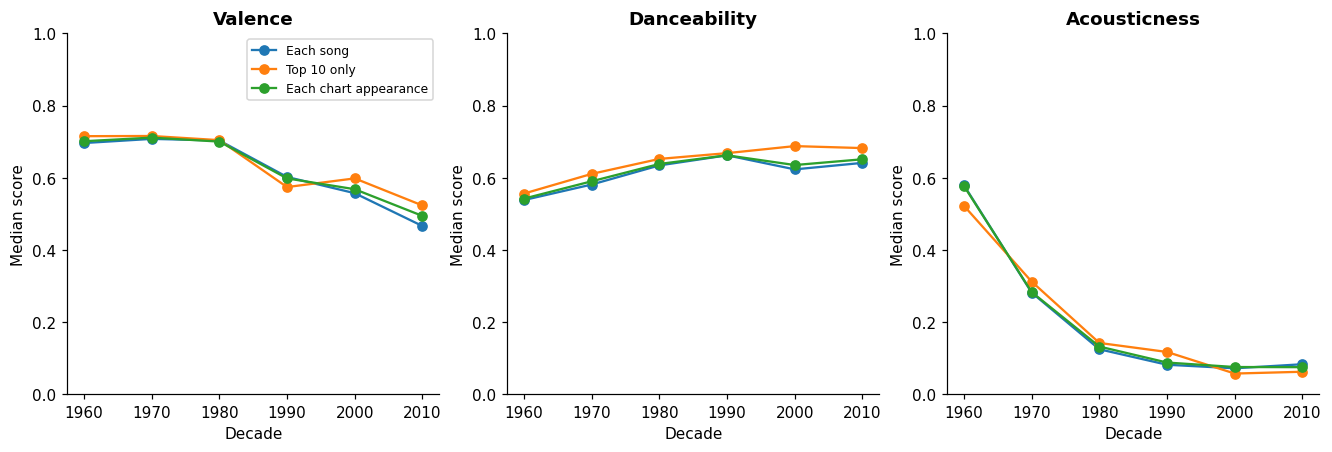

,valence,danceability,energy,acousticness
Song medians,-0.230,0.103,0.180,-0.496
Song means,-0.185,0.107,0.152,-0.343
Available scores individually,-0.230,0.103,0.180,-0.496
Top 10 medians,-0.192,0.126,0.174,-0.460
Chart-appearance medians,-0.207,0.109,0.194,-0.502


decade
1960     5.8
1970     9.6
1980    16.2
1990    27.7
2000    25.4
2010    40.7
Name: Top-10 songs with lower valence and higher danceability (%), dtype: float64

In [54]:
chart_sample = entries[entries.chart_year.between(1960, 2019)].copy()
chart_sample = chart_sample.merge(songs[['song_id', 'eda_core_complete'] + scores],
                                  on='song_id', how='left', validate='m:1')
assert len(chart_sample) == entries.chart_year.between(1960, 2019).sum()
chart_sample['decade'] = chart_sample.chart_year // 10 * 10
chart_medians = chart_sample[chart_sample.eda_core_complete].groupby('decade')[scores].median()
top10_medians = audio[audio.top10].groupby('decade')[scores].median()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, score in zip(axes, ['valence', 'danceability', 'acousticness']):
    ax.plot(medians.index, medians[score], marker='o', label='Each song')
    ax.plot(top10_medians.index, top10_medians[score], marker='o', label='Top 10 only')
    ax.plot(chart_medians.index, chart_medians[score], marker='o', label='Each chart appearance')
    ax.set(title=score.capitalize(), xlabel='Decade', ylabel='Median score', ylim=(0, 1))
axes[0].legend(fontsize=8)
plt.show()

# Means and feature-specific samples provide two more simple checks.
comparison_tables = {
    'Song medians': medians,
    'Song means': audio.groupby('decade')[scores].mean(),
    'Available scores individually': sample.groupby('decade')[scores].median(),
    'Top 10 medians': top10_medians,
    'Chart-appearance medians': chart_medians,
}
changes = {}
for name, table in comparison_tables.items():
    changes[name] = table.loc[2010] - table.loc[1960]
display(pd.DataFrame(changes).T.round(3))

joint_top10 = audio[audio.top10].groupby('decade').low_valence_danceable.mean() * 100
display(joint_top10.round(1).rename('Top-10 songs with lower valence and higher danceability (%)'))


The direction of the valence, danceability, and acousticness changes survives these comparisons. The lower-valence/higher-danceability share also rises from about 5.8% to 40.7% among top-10 songs alone. Chart appearances retain the documented double entries because the unit here is a chart entry, not a unique song-week.

These checks make the patterns less dependent on one plotting choice. They do not recover missing audio, verify recording matches, or turn the results into causal explanations. We are exploring multiple possibilities, so these are descriptive findings rather than a set of preplanned statistical tests.

## 10. Choosing the report story and figures

The main decision is whether to tell one connected history of the sound of hits or focus more narrowly on genre and what the data can capture. We do not need every plot in the report.


| Possible story | What supports it | Figures to use | Decision |
|---|---|---|---|
| **Lower valence, still danceable** | The joint pattern rises with different cutoffs, performer weighting, and top-10 restriction | Two-decade valence/danceability comparison plus a share-over-time line | Strongest lead |
| **Short songs are making a comeback** | Length rises and then falls; under-three-minute songs return but remain less common than in the 1960s | Duration distributions and under-three-minute share; annual detail if needed | Strong alternative lead or supporting section |
| **The acoustic shift happened earlier** | The largest decline precedes the 1990s; the endpoint mean decline survives unrestricted missing-score bounds | Overall acousticness trend and selected within-genre lines | Useful historical context |
| **More than a change in genre** | Valence still falls when the mix of five large buckets is held fixed | Genre composition and fixed-mix mean valence | Potentially strong supporting section after tag review |
| **What kinds of hits are missing?** | Unlabeled songs have low audio coverage in every decade; filtering changes genre representation | Coverage heatmap, genre-share difference, and missing-audio scenario check | Methods sidebar or a separate data-quality story |
| **The danceability gap depends on genre** | Pop has a consistent recent top-10 gap; rap does not | Top-10 difference by genre and decade, with sample sizes | Optional supporting result, not a universal hit formula |

**Our choice is a three-part story about how the sound of hits changed at different times.** We lead with lower valence and higher danceability, using the paired distributions and the share-over-time line. We then use the acousticness trend to put that change in a longer history: much of the shift toward lower acousticness happened earlier, and its endpoint mean decline is especially robust to missing scores. We finish with song length, where the rise and later fall challenge the idea that hits have simply been getting shorter throughout the period.

Genre helps us qualify that story rather than carry the main headline. The within-genre comparisons and fixed-mix calculation suggest that changing genre proportions are not the whole explanation, but the tags are not reliable enough for precise claims about which genres drove the change. The coverage results and missing-audio scenarios belong in a short methods discussion alongside the main figures.

We keep the top-10 danceability result as a supporting finding rather than a separate main section. Its genre differences are interesting, but it would pull the report toward explaining chart success, which this analysis cannot establish. The selected story stays descriptive: changes in the matched recordings of U.S. charting songs, with clear limits on what missing data, genre labels, and algorithmic scores allow us to conclude.
